#Install required libraries

In [ ]:
!pip install pandas scikit-learn seaborn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import string

#Job Posting CSV creation

In [ ]:
import pandas as pd
import numpy as np

skills_pool = [
    "Python", "Machine Learning", "Data Analysis", "SQL", "TensorFlow",
    "React", "JavaScript", "UI/UX", "HTML", "CSS",
    "Cloud Computing", "AWS", "Docker", "Kubernetes",
    "Project Management", "Agile", "Java", "C++", "Communication", "Leadership"
]

job_titles = [
    "Data Scientist", "Machine Learning Engineer", "Frontend Developer", "Backend Developer",
    "Full Stack Developer", "Cloud Engineer", "DevOps Engineer", "Project Manager",
    "Software Engineer", "Data Analyst", "Product Manager", "UI/UX Designer"
]

num_jobs = 200
np.random.seed(42)

descriptions = []
titles = []

for _ in range(num_jobs):
    num_skills = np.random.randint(5, 11)
    selected_skills = np.random.choice(skills_pool, size=num_skills, replace=False)
    descriptions.append(" ".join(selected_skills))
    titles.append(np.random.choice(job_titles))

df_jobs = pd.DataFrame({
    "S.No.": range(1, num_jobs + 1),
    "Job Title": titles,
    "Job Description": descriptions
})

df_jobs.to_csv("mock_job_postings.csv", index=False)

df_jobs.head()

,S.No.,Job Title,Job Description
0,1,Machine Learning Engineer,Python Kubernetes HTML Machine Learning Agile ...
1,2,Software Engineer,Machine Learning Kubernetes HTML React TensorF...
2,3,Cloud Engineer,Cloud Computing Java Project Management Agile ...
3,4,UI/UX Designer,Data Analysis Python React Docker Cloud Comput...
4,5,Data Scientist,Machine Learning TensorFlow React SQL Cloud Co...


#Load Simulated Job Data

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving mock_job_postings.csv to mock_job_postings (1).csv


,S.No.,Job Title,Job Description
0,1,Machine Learning Engineer,Python Kubernetes HTML Machine Learning Agile ...
1,2,Software Engineer,Machine Learning Kubernetes HTML React TensorF...
2,3,Cloud Engineer,Cloud Computing Java Project Management Agile ...
3,4,UI/UX Designer,Data Analysis Python React Docker Cloud Comput...
4,5,Data Scientist,Machine Learning TensorFlow React SQL Cloud Co...


#Preprocess text

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text
df['clean_description'] = df['Job Description'].astype(str).apply(preprocess_text)

#Vectorizing Text for Skill Extraction

In [ ]:
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['clean_description'])

skill_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
skill_df.head()

,agile,analysis,aws,cloud,communication,computing,css,data,docker,html,...,leadership,learning,machine,management,project,python,react,sql,tensorflow,uiux
0,1,0,1,0,0,0,0,0,0,1,...,1,1,1,0,0,1,1,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,1,0,1,0,1,1
2,1,0,0,1,1,1,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,1,1,0,1,0,1,0,1,1,1,...,0,0,0,1,1,1,1,0,1,0
4,0,1,0,1,0,1,0,1,0,0,...,0,1,1,0,0,0,1,1,1,0


#Computing Skill Co-occurrence Matrix

In [ ]:
# Co-occurrence = term-document matrix transposed * term-document matrix
co_occurrence_matrix = (X.T * X)
co_occurrence_matrix.setdiag(0)

co_occurrence_df = pd.DataFrame(
    co_occurrence_matrix.toarray(),
    index=vectorizer.get_feature_names_out(),
    columns=vectorizer.get_feature_names_out()
)

#Select Top 20 Skills

In [ ]:
top_skills = co_occurrence_df.sum(axis=1).sort_values(ascending=False).head(20).index
top_co_occurrence = co_occurrence_df.loc[top_skills, top_skills]

#Ploting Heatmap

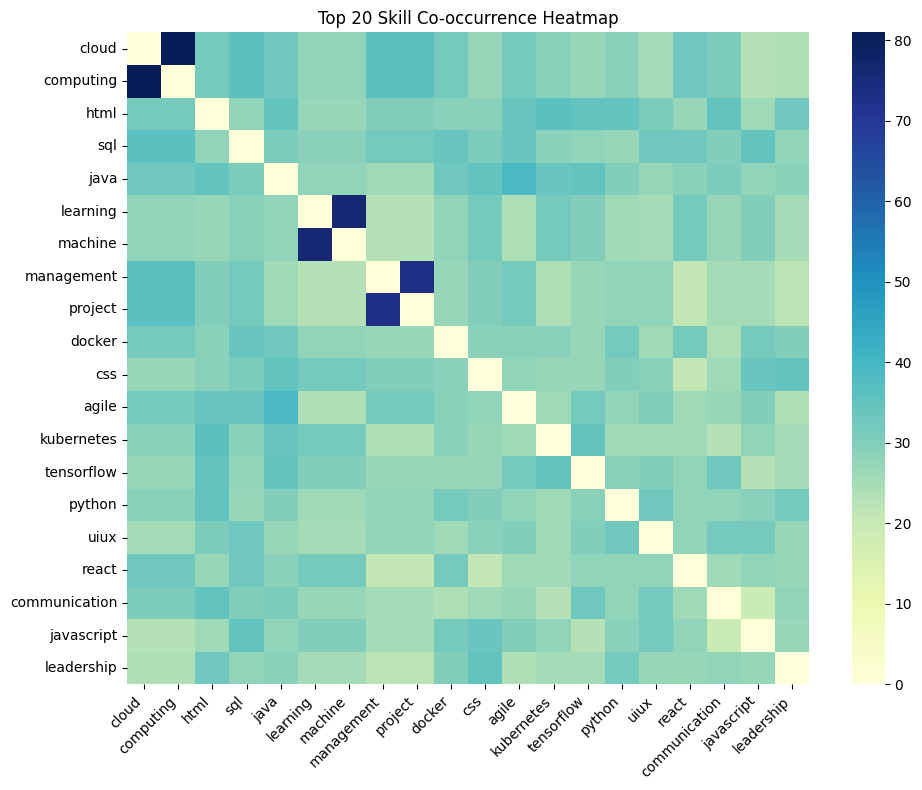

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(top_co_occurrence, cmap="YlGnBu", xticklabels=True, yticklabels=True)
plt.title("Top 20 Skill Co-occurrence Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*   **Strong skill pairings** like Cloud–Computing, Machine–Learning, and Project–Management stand out, showing frequent joint demand.

*   **Technical clusters** form naturally — e.g., Python–TensorFlow–ML (data roles) and HTML–CSS–React–JavaScript (frontend roles).

*   **DevOps skills** (Cloud, Docker, Kubernetes) frequently appear together, indicating clear infrastructure-focused job clusters.

*   **Soft skills** (Communication, Leadership) co-occur with technical skills but at lower intensity, highlighting their supporting role.